In [23]:
from pathlib import Path

import numpy as np
import pandas as pd

import sys
sys.path.append(r'../src')
from eda_utils import *

The code is based on the following folder structure:

project/

├── data/

│ └── csv aggregated datasets

└── src/

│ └──province_transformation.py

│ └── eda_utils.py

└── notebooks
│ └──Eda_produzione-ipynb


In particular:

province_transformation.py contains a collection of utilities used to apply the necessary transformation to each province csv file
eda_utils.py contains a collection of utilities used for exploratory data analysis

In [24]:
#CURRENT_DIR = Path.cwd().resolve()

#PROJECT_ROOT = CURRENT_DIR.parent

#DATA_DIR = '.. /data'

In [25]:
# This file is the result of the previous step of transformation and aggregation of all province dataset
#PRODUCTION_DATA = DATA_DIR / "production_full_dataset.csv"

In [26]:
#Riga inserita per importare i dati dal mio computer locale
PRODUCTION_DATA= r"C:\Users\Andrea\master\Capston\production_full_dataset.csv"

In [27]:
df = pd.read_csv(PRODUCTION_DATA)

display(df.head())
display(df.tail())

df.info()

,province,year,crop_name,area,production,yield,q_cv_group,q_area_coverage,q_n_regions_used,q_n_expected_regions,q_n_missing_regions,q_n_structural_zero_regions,q_source_status,q_apy_incoherent,q_calculated_region
0,Agrigento,1995,Durum wheat,50190.0,79199.8,1.578000,Agrigento,1.0,1,1,0,0,complete,False,False
1,Agrigento,1996,Durum wheat,51520.0,114776.2,2.227799,Agrigento,1.0,1,1,0,0,complete,False,False
2,Agrigento,1997,Durum wheat,50200.0,120480.0,2.400000,Agrigento,1.0,1,1,0,0,complete,False,False
3,Agrigento,1998,Durum wheat,34039.0,81693.6,2.400000,Agrigento,1.0,1,1,0,0,complete,False,False
4,Agrigento,1999,Durum wheat,48000.0,96000.0,2.000000,Agrigento,1.0,1,1,0,0,complete,False,False


,province,year,crop_name,area,production,yield,q_cv_group,q_area_coverage,q_n_regions_used,q_n_expected_regions,q_n_missing_regions,q_n_structural_zero_regions,q_source_status,q_apy_incoherent,q_calculated_region
7571,Viterbo,2021,Grain maize,1770.0,17170.0,9.700565,Viterbo,1.0,1,1,0,0,complete,False,False
7572,Viterbo,2021,Soft wheat,2690.0,12850.0,4.776952,Viterbo,1.0,1,1,0,0,complete,False,False
7573,Viterbo,2022,Durum wheat,19740.0,62900.0,3.186424,Viterbo,1.0,1,1,0,0,complete,False,False
7574,Viterbo,2022,Grain maize,1770.0,17000.0,9.604520,Viterbo,1.0,1,1,0,0,complete,False,False
7575,Viterbo,2022,Soft wheat,2680.0,11300.0,4.216418,Viterbo,1.0,1,1,0,0,complete,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7576 entries, 0 to 7575
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   province                     7576 non-null   object 
 1   year                         7576 non-null   int64  
 2   crop_name                    7576 non-null   object 
 3   area                         7576 non-null   float64
 4   production                   7576 non-null   float64
 5   yield                        7576 non-null   float64
 6   q_cv_group                   7576 non-null   object 
 7   q_area_coverage              7576 non-null   float64
 8   q_n_regions_used             7576 non-null   int64  
 9   q_n_expected_regions         7576 non-null   int64  
 10  q_n_missing_regions          7576 non-null   int64  
 11  q_n_structural_zero_regions  7576 non-null   int64  
 12  q_source_status              7576 non-null   object 
 13  q_apy_incoherent  

In [28]:
pd.set_option('display.max_rows', None)
summarize_columns(df)
pd.reset_option('display.max_rows')

,Column,Data Type,Total Values,Unique Values,NaN Values,NaN %
0,province,object,7576,105,0,0.0
1,year,int64,7576,28,0,0.0
2,crop_name,object,7576,3,0,0.0
3,area,float64,7576,3473,0,0.0
4,production,float64,7576,5727,0,0.0
5,yield,float64,7576,4898,0,0.0
6,q_cv_group,object,7576,97,0,0.0
7,q_area_coverage,float64,7576,12,0,0.0
8,q_n_regions_used,int64,7576,3,0,0.0
9,q_n_expected_regions,int64,7576,3,0,0.0


**Dataset overview**

The dataset contains both the production variables and the observation-level quality metadata. Columns prefixed with q_ describe territorial coverage, the number of expected and available source regions, missing source data, structural-zero components, APY incoherence, NUTS reconstruction and the grouping constraints required for model validation.
Missing source data are never replaced with zero. Explicit structural zeros are identified separately. Province-crop-year cells whose total Area is zero are retained in non_target_df for documentation but are excluded from the modelling panel because Yield is undefined.

The panel contains 7,576 observations for 105 provinces, 28 years and three crops. Its key is (province, year, crop_name), and duplicate keys are not allowed.

In [29]:
df.columns

Index(['province', 'year', 'crop_name', 'area', 'production', 'yield',
       'q_cv_group', 'q_area_coverage', 'q_n_regions_used',
       'q_n_expected_regions', 'q_n_missing_regions',
       'q_n_structural_zero_regions', 'q_source_status', 'q_apy_incoherent',
       'q_calculated_region'],
      dtype='object')

In [30]:
df["crop_name"].unique()

array(['Durum wheat', 'Grain maize', 'Soft wheat'], dtype=object)

In [36]:
#I create separate copies of the DataFrame for each wheat type.
q_columns=['q_cv_group', 'q_area_coverage', 'q_n_regions_used',
       'q_n_expected_regions', 'q_n_missing_regions',
       'q_n_structural_zero_regions', 'q_source_status', 'q_apy_incoherent',
       'q_calculated_region']
soft_wheat_df  = df[df["crop_name"] == "Soft wheat" ].drop(columns=q_columns).copy()
durum_wheat_df = df[df["crop_name"] == "Durum wheat"].drop(columns=q_columns).copy()
grain_maize_df = df[df["crop_name"] == "Grain maize"].drop(columns=q_columns).copy()

### Missing year-province combination
Before starting the univariate analysis, I display the missing year–province combinations to draw the correct conclusions.


In [71]:
#I check which year–province combinations are missing.
df_new=df.drop(columns=q_columns).copy()
province = df_new["province"].unique()
years = df_new["year"].unique()

atteso = pd.MultiIndex.from_product([province, years], names=["province", "year"])
reale = pd.MultiIndex.from_frame(df_new[["province", "year"]])
mancanti = atteso.difference(reale)

mancanti=pd.DataFrame(list(mancanti), columns=["province", "year"])

display(mancanti.head())
display(mancanti.tail())
display(mancanti.shape)

,province,year
0,Biella,1995
1,Biella,1996
2,Crotone,1995
3,Genova,2021
4,Genova,2022


,province,year
14,Trieste,2022
15,Valle d'Aosta / Vallée d'Aoste,2019
16,Valle d'Aosta / Vallée d'Aoste,2020
17,Verbano-Cusio-Ossola,1995
18,Vibo Valentia,1995


(19, 2)

In [72]:
display(mancanti["province"].unique())
display(len(mancanti["province"].unique()))

array(['Biella', 'Crotone', 'Genova', 'Lecco', 'Lodi', 'Prato',
       'Provincia Autonoma di Bolzano / Autonome Provinz Bozen', 'Rimini',
       'Trieste', "Valle d'Aosta / Vallée d'Aoste",
       'Verbano-Cusio-Ossola', 'Vibo Valentia'], dtype=object)

12

In [73]:
mancanti.groupby("year").size()

year
1995    7
1996    3
2019    2
2020    3
2021    2
2022    2
dtype: int64

In [74]:
mancanti.groupby("year")["province"].apply(list)

year
1995    [Biella, Crotone, Lodi, Prato, Rimini, Verbano...
1996                                [Biella, Lecco, Lodi]
2019    [Provincia Autonoma di Bolzano / Autonome Prov...
2020    [Provincia Autonoma di Bolzano / Autonome Prov...
2021                                    [Genova, Trieste]
2022                                    [Genova, Trieste]
Name: province, dtype: object

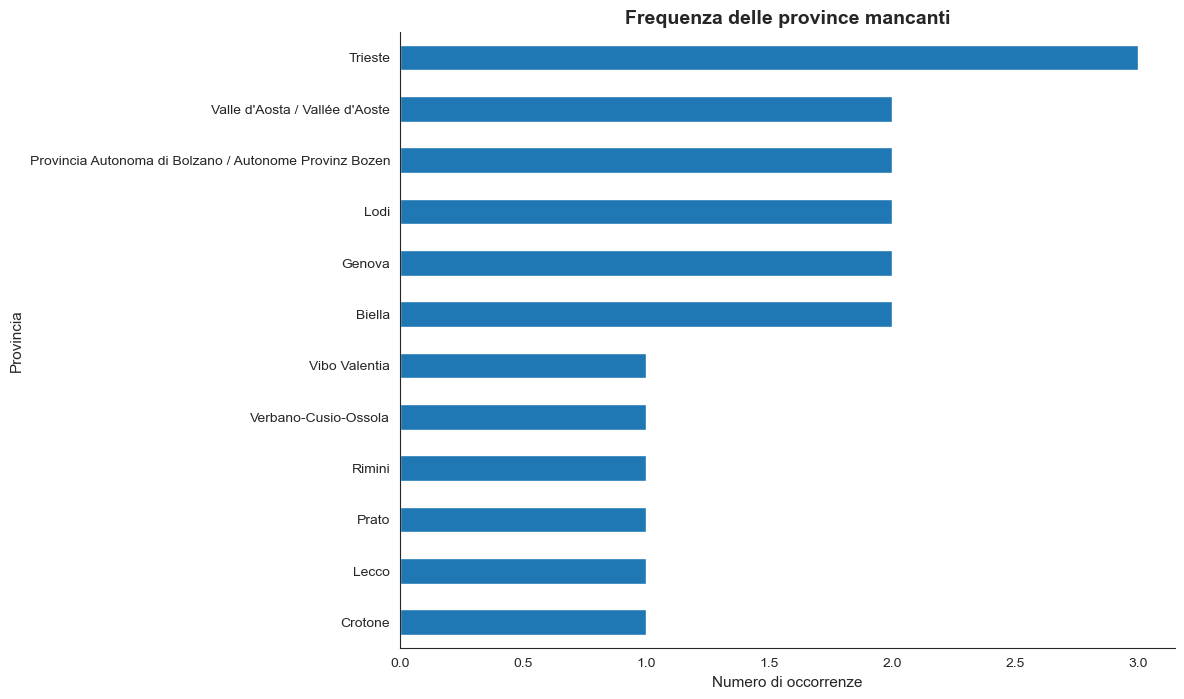

In [79]:
plt.figure(figsize=(10, 8))
mancanti["province"].value_counts().sort_values().plot(kind="barh")
plt.title("Frequenza delle province mancanti")
plt.xlabel("Numero di occorrenze")
plt.ylabel("Provincia")
plt.show()

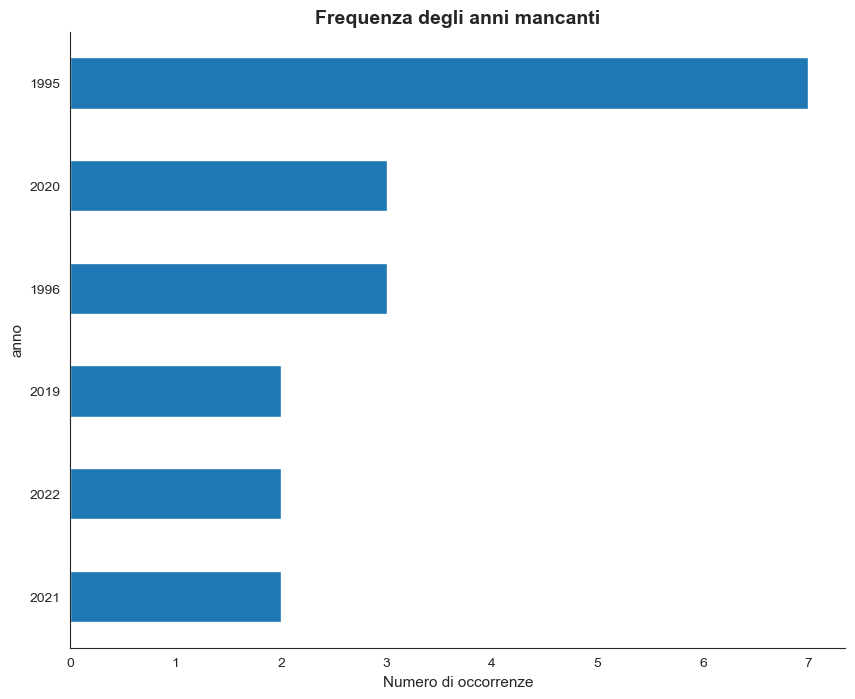

In [80]:
plt.figure(figsize=(10, 8))
mancanti["year"].value_counts().sort_values().plot(kind="barh")
plt.title("Frequenza degli anni mancanti")
plt.xlabel("Numero di occorrenze")
plt.ylabel("anno")
plt.show()

From this analysis, we deduce that there are 19 missing combinations of province-year. 

Consequently, the following analysis will be carried out excluding those 19 combinations.

### Soft Wheat - Univariate Analisys

In [82]:
display(soft_wheat_df.head())
display(soft_wheat_df.tail())

soft_wheat_df.info()

,province,year,crop_name,area,production,yield
30,Alessandria,1995,Soft wheat,54500.0,297352.0,5.456000
33,Alessandria,1996,Soft wheat,60000.0,344190.0,5.736500
36,Alessandria,1997,Soft wheat,41280.0,143934.0,3.486773
39,Alessandria,1998,Soft wheat,42115.0,240640.0,5.713879
42,Alessandria,1999,Soft wheat,44015.0,223766.0,5.083858


,province,year,crop_name,area,production,yield
7563,Viterbo,2018,Soft wheat,2450.0,11100.0,4.530612
7566,Viterbo,2019,Soft wheat,2800.0,13800.0,4.928571
7569,Viterbo,2020,Soft wheat,2700.0,13200.0,4.888889
7572,Viterbo,2021,Soft wheat,2690.0,12850.0,4.776952
7575,Viterbo,2022,Soft wheat,2680.0,11300.0,4.216418


<class 'pandas.core.frame.DataFrame'>
Index: 2485 entries, 30 to 7575
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   province    2485 non-null   object 
 1   year        2485 non-null   int64  
 2   crop_name   2485 non-null   object 
 3   area        2485 non-null   float64
 4   production  2485 non-null   float64
 5   yield       2485 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 200.4+ KB


In [85]:
#I verify how many missing combinations there are for soft_wheat.
province = soft_wheat_df["province"].unique()
years = soft_wheat_df["year"].unique()

atteso = pd.MultiIndex.from_product([province, years], names=["province", "year"])
reale = pd.MultiIndex.from_frame(soft_wheat_df[["province", "year"]])
mancanti_soft = atteso.difference(reale)

mancanti_soft=pd.DataFrame(list(mancanti_soft), columns=["province", "year"])

display(mancanti_soft.head())
display(mancanti_soft.tail())
display(mancanti_soft.shape)

,province,year
0,Area vasta Sud Sardegna,1995
1,Area vasta Sud Sardegna,1996
2,Area vasta Sud Sardegna,1997
3,Area vasta Sud Sardegna,1998
4,Area vasta Sud Sardegna,1999


,province,year
254,Verbano-Cusio-Ossola,1996
255,Verbano-Cusio-Ossola,2005
256,Verbano-Cusio-Ossola,2016
257,Vibo Valentia,1995
258,Vibo Valentia,1996


(259, 2)

In [86]:
display(mancanti_soft["province"].unique())
display(len(mancanti_soft["province"].unique()))

array(['Area vasta Sud Sardegna', 'Bari', 'Barletta-Andria-Trani',
       'Belluno', 'Biella', 'Catania', 'Crotone', 'Genova', 'Lecce',
       'Lecco', 'Lodi', 'Matera', 'Napoli', 'Novara', 'Nuoro', 'Oristano',
       'Perugia', 'Pistoia', 'Prato',
       'Provincia Autonoma di Bolzano / Autonome Provinz Bozen',
       'Reggio Calabria', 'Rimini', 'Sassari', 'Sondrio', 'Trento',
       'Trieste', "Valle d'Aosta / Vallée d'Aoste",
       'Verbano-Cusio-Ossola', 'Vibo Valentia'], dtype=object)

29

We can observe that soft wheat has 259 missing combinations. For now, I will limit the univariate analysis to provinces that do not have missing combinations. These 29 provinces will be considered later.

In [87]:
non_numeric_columns= ['province','year','crop_name']
soft_wheat_df_full = soft_wheat_df[~soft_wheat_df["province"].isin(mancanti_soft["province"].unique())].copy()
display(soft_wheat_df_full.drop(columns=['province','year','crop_name']).describe(include='all').T)

,count,mean,std,min,25%,50%,75%,max
area,1932.0,7867.160104,8660.881360,6.000000,1750.750000,4482.500000,11262.500000,60000.000000
production,1932.0,40116.290088,51080.853655,15.000000,6000.000000,17999.500000,56962.500000,344190.000000
yield,1932.0,4.365217,1.404872,0.297973,3.324972,4.293892,5.425059,8.522973


Detected type for 'area': continuous
'area': 0 missing (0.0%)
Skew: 1.797


,count,mean,std,min,25%,50%,75%,max
area,1932.0,7867.160104,8660.88136,6.0,1750.75,4482.5,11262.5,60000.0


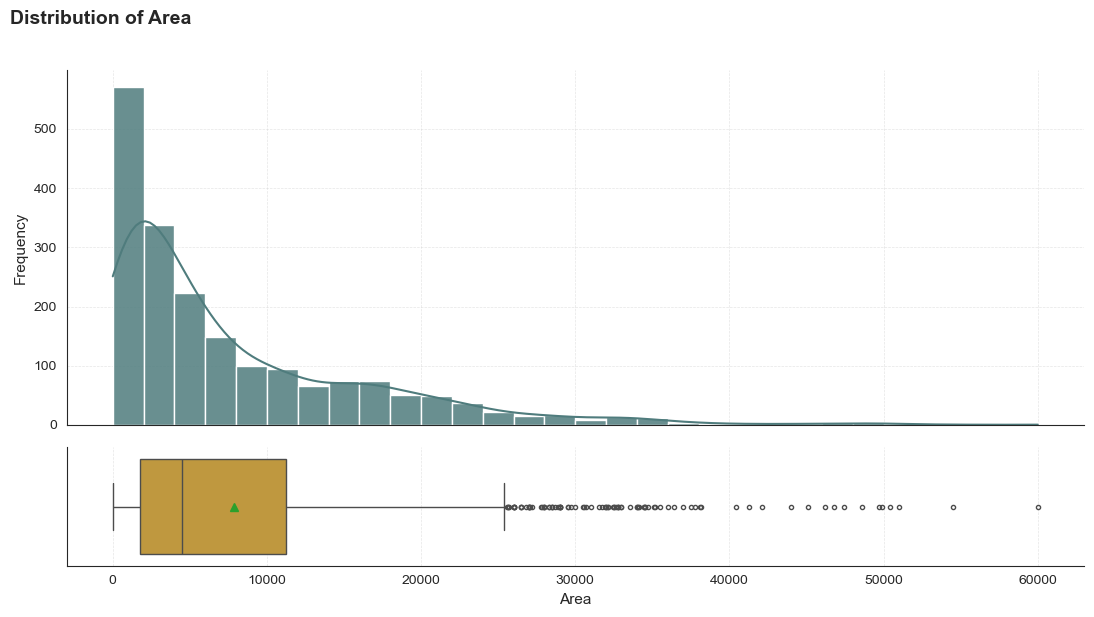

Detected type for 'production': continuous
'production': 0 missing (0.0%)
Skew: 1.976


,count,mean,std,min,25%,50%,75%,max
production,1932.0,40116.290088,51080.853655,15.0,6000.0,17999.5,56962.5,344190.0


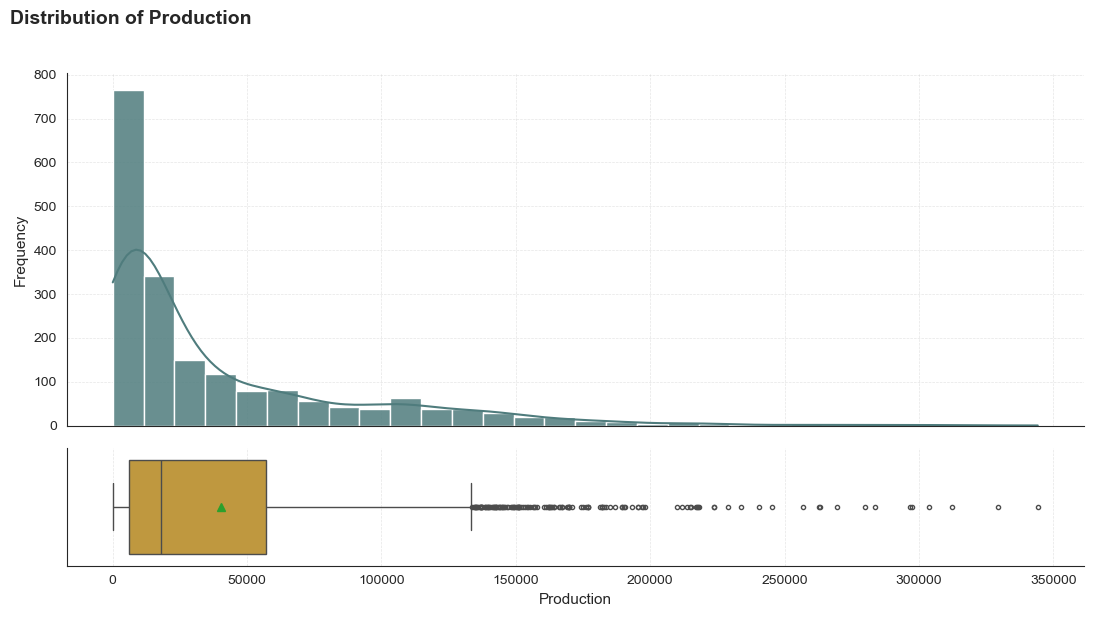

Detected type for 'yield': continuous
'yield': 0 missing (0.0%)
Skew: 0.057


,count,mean,std,min,25%,50%,75%,max
yield,1932.0,4.365217,1.404872,0.297973,3.324972,4.293892,5.425059,8.522973


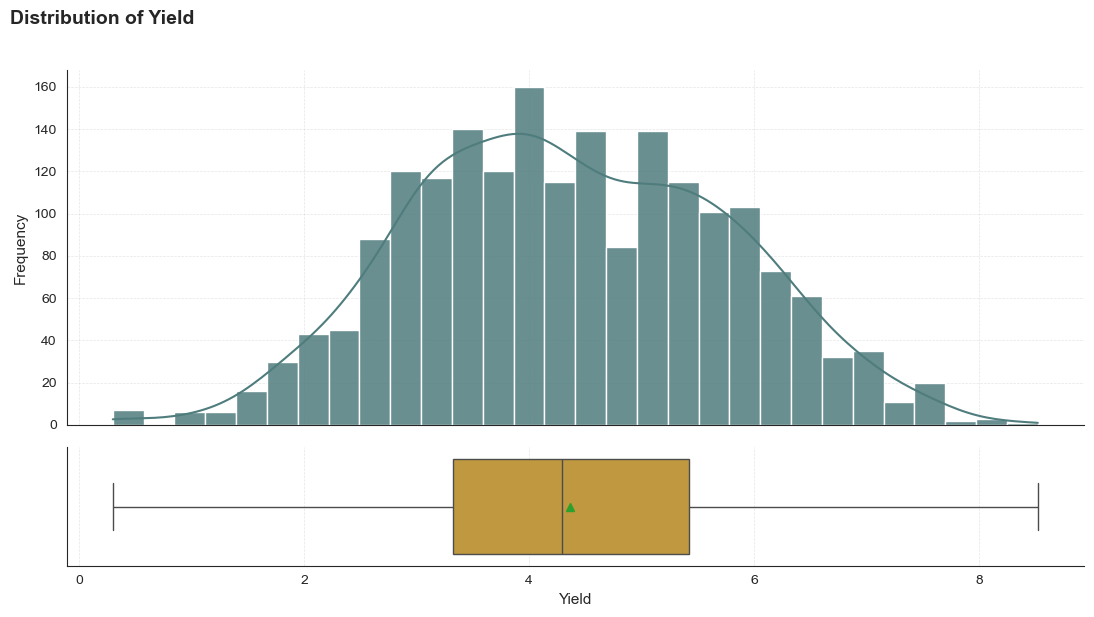

In [88]:
for c in soft_wheat_df_full.columns[3:]:
    kind = infer_variable_type(soft_wheat_df_full[c])
    if kind == "continuous":
        describe_variable(soft_wheat_df_full, c, auto_log = False)
    else:
        describe_variable(soft_wheat_df_full, c)

### Durum Wheat - Univariate Analisys¶

In [89]:
display(durum_wheat_df.head())
display(durum_wheat_df.tail())

durum_wheat_df.info()

,province,year,crop_name,area,production,yield
0,Agrigento,1995,Durum wheat,50190.0,79199.8,1.578000
1,Agrigento,1996,Durum wheat,51520.0,114776.2,2.227799
2,Agrigento,1997,Durum wheat,50200.0,120480.0,2.400000
3,Agrigento,1998,Durum wheat,34039.0,81693.6,2.400000
4,Agrigento,1999,Durum wheat,48000.0,96000.0,2.000000


,province,year,crop_name,area,production,yield
7561,Viterbo,2018,Durum wheat,20200.0,75000.0,3.712871
7564,Viterbo,2019,Durum wheat,19500.0,78000.0,4.000000
7567,Viterbo,2020,Durum wheat,19700.0,74850.0,3.799492
7570,Viterbo,2021,Durum wheat,19720.0,73500.0,3.727181
7573,Viterbo,2022,Durum wheat,19740.0,62900.0,3.186424


<class 'pandas.core.frame.DataFrame'>
Index: 2431 entries, 0 to 7573
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   province    2431 non-null   object 
 1   year        2431 non-null   int64  
 2   crop_name   2431 non-null   object 
 3   area        2431 non-null   float64
 4   production  2431 non-null   float64
 5   yield       2431 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 132.9+ KB


In [91]:
#I verify how many missing combinations there are for soft_wheat.
province = durum_wheat_df["province"].unique()
years = durum_wheat_df["year"].unique()

atteso = pd.MultiIndex.from_product([province, years], names=["province", "year"])
reale = pd.MultiIndex.from_frame(durum_wheat_df[["province", "year"]])
mancanti_durum = atteso.difference(reale)

mancanti_durum=pd.DataFrame(list(mancanti_durum), columns=["province", "year"])

display(mancanti_durum.head())
display(mancanti_durum.tail())
display(mancanti_durum.shape)

,province,year
0,Asti,1995
1,Asti,1996
2,Asti,1997
3,Asti,1998
4,Asti,1999


,province,year
364,Vicenza,2003
365,Vicenza,2004
366,Vicenza,2005
367,Vicenza,2006
368,Vicenza,2007


(369, 2)

In [92]:
display(mancanti_durum["province"].unique())
display(len(mancanti_durum["province"].unique()))

array(['Asti', 'Belluno', 'Bergamo', 'Biella', 'Brescia', 'Como',
       'Crotone', 'Cuneo', 'Genova', 'Gorizia', 'La Spezia', 'Lodi',
       'Milano', 'Monza e della Brianza', 'Novara', 'Pordenone', 'Prato',
       "Reggio nell'Emilia", 'Rimini', 'Sondrio', 'Torino', 'Trento',
       'Trieste', 'Udine', "Valle d'Aosta / Vallée d'Aoste", 'Varese',
       'Venezia', 'Vercelli', 'Vibo Valentia', 'Vicenza'], dtype=object)

30

In [94]:
non_numeric_columns= ['province','year','crop_name']
durum_wheat_df_full = durum_wheat_df[~durum_wheat_df["province"].isin(mancanti_durum["province"].unique())].copy()
display(durum_wheat_df_full.drop(columns=['province','year','crop_name']).describe(include='all').T)

,count,mean,std,min,25%,50%,75%,max
area,1960.0,20250.601362,33583.789774,3.000,2100.000000,9817.500000,25000.000000,279371.830000
production,1960.0,58950.284230,94843.616705,13.200,6901.125000,31266.000000,74342.600000,965580.000000
yield,1960.0,3.499838,1.345485,0.194,2.581997,3.238288,4.355277,8.142377


Detected type for 'area': continuous
'area': 0 missing (0.0%)
Skew: 4.445


,count,mean,std,min,25%,50%,75%,max
area,1960.0,20250.601362,33583.789774,3.0,2100.0,9817.5,25000.0,279371.83


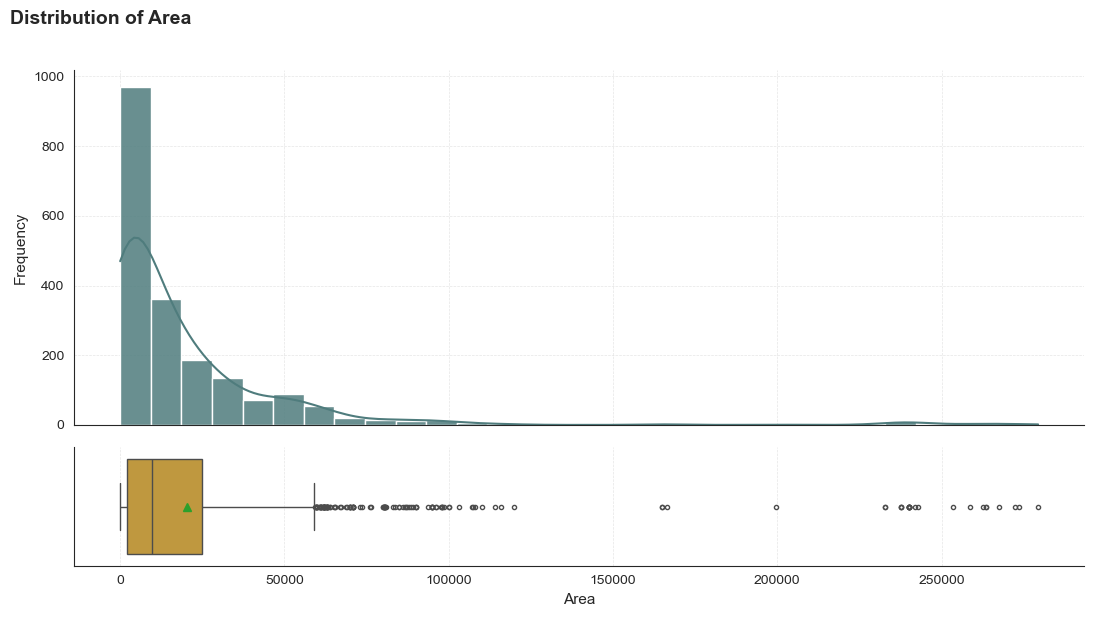

Detected type for 'production': continuous
'production': 0 missing (0.0%)
Skew: 4.770


,count,mean,std,min,25%,50%,75%,max
production,1960.0,58950.28423,94843.616705,13.2,6901.125,31266.0,74342.6,965580.0


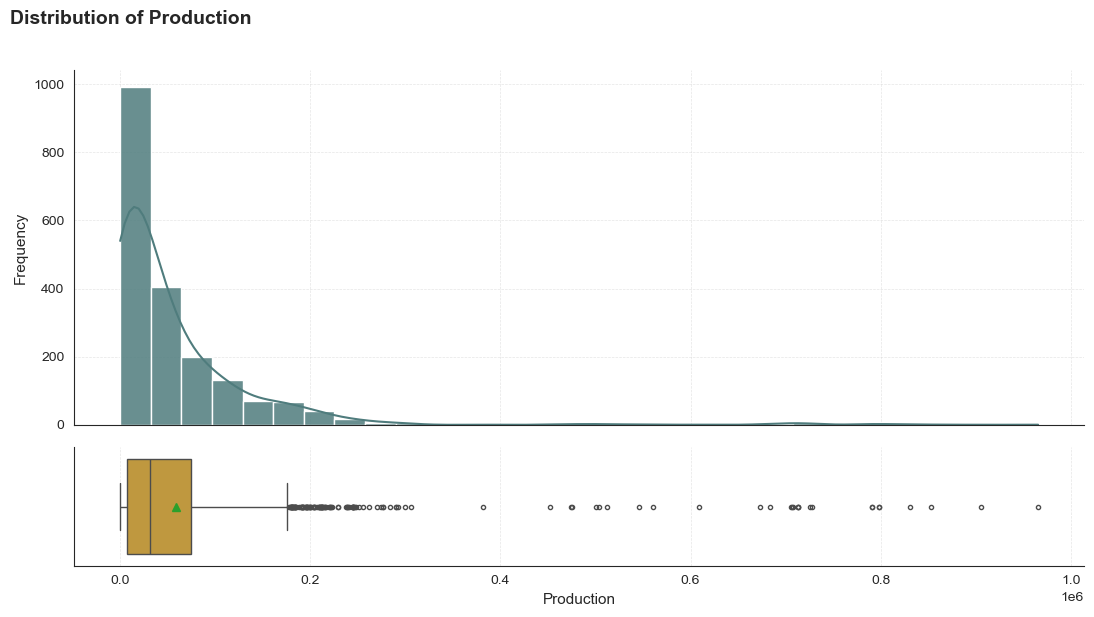

Detected type for 'yield': continuous
'yield': 0 missing (0.0%)
Skew: 0.531


,count,mean,std,min,25%,50%,75%,max
yield,1960.0,3.499838,1.345485,0.194,2.581997,3.238288,4.355277,8.142377


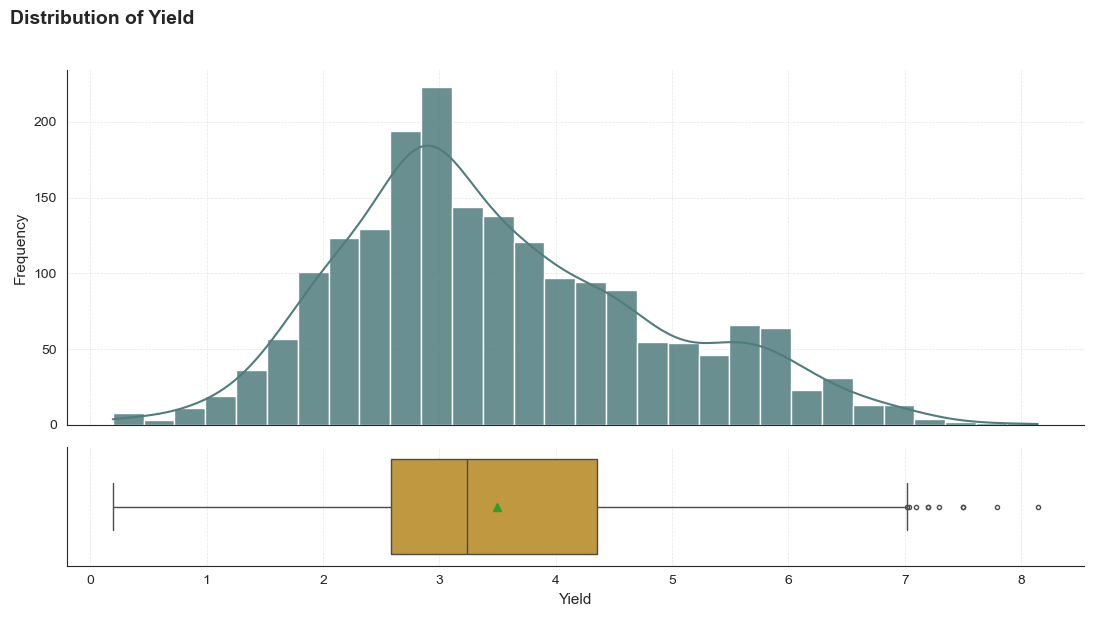

In [95]:
for c in durum_wheat_df_full.columns[3:]:
    kind = infer_variable_type(durum_wheat_df_full[c])
    if kind == "continuous":
        describe_variable(durum_wheat_df_full, c, auto_log = False)
    else:
        describe_variable(soft_wheat_df_full, c)

### Grain maize - Univariate Analisys¶

In [96]:
display(grain_maize_df.head())
display(grain_maize_df.tail())

grain_maize_df.info()

,province,year,crop_name,area,production,yield
29,Alessandria,1995,Grain maize,33000.0,257400.0,7.800000
32,Alessandria,1996,Grain maize,27070.0,216558.0,7.999926
35,Alessandria,1997,Grain maize,25850.0,167880.0,6.494391
38,Alessandria,1998,Grain maize,21450.0,157500.0,7.342657
41,Alessandria,1999,Grain maize,21300.0,157500.0,7.394366


,province,year,crop_name,area,production,yield
7562,Viterbo,2018,Grain maize,1800.0,18820.0,10.455556
7565,Viterbo,2019,Grain maize,1800.0,17600.0,9.777778
7568,Viterbo,2020,Grain maize,1770.0,17600.0,9.943503
7571,Viterbo,2021,Grain maize,1770.0,17170.0,9.700565
7574,Viterbo,2022,Grain maize,1770.0,17000.0,9.604520


<class 'pandas.core.frame.DataFrame'>
Index: 2660 entries, 29 to 7574
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   province    2660 non-null   object 
 1   year        2660 non-null   int64  
 2   crop_name   2660 non-null   object 
 3   area        2660 non-null   float64
 4   production  2660 non-null   float64
 5   yield       2660 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 145.5+ KB


In [98]:
#I verify how many missing combinations there are for soft_wheat.
province = grain_maize_df["province"].unique()
years = grain_maize_df["year"].unique()

atteso = pd.MultiIndex.from_product([province, years], names=["province", "year"])
reale = pd.MultiIndex.from_frame(grain_maize_df[["province", "year"]])
mancanti_maize = atteso.difference(reale)

mancanti_maize=pd.DataFrame(list(mancanti_maize), columns=["province", "year"])

display(mancanti_maize.head())
display(mancanti_maize.tail())
display(mancanti_maize.shape)


,province,year
0,Area vasta Sud Sardegna,2010
1,Area vasta Sud Sardegna,2020
2,Area vasta Sud Sardegna,2021
3,Area vasta Sud Sardegna,2022
4,Bari,1995


,province,year
135,Valle d'Aosta / Vallée d'Aoste,1995
136,Valle d'Aosta / Vallée d'Aoste,2019
137,Valle d'Aosta / Vallée d'Aoste,2020
138,Verbano-Cusio-Ossola,1995
139,Vibo Valentia,1995


(140, 2)

In [99]:
display(mancanti_maize["province"].unique())
display(len(mancanti_maize["province"].unique()))

array(['Area vasta Sud Sardegna', 'Bari', 'Barletta-Andria-Trani',
       'Biella', 'Crotone', 'Genova', 'Lecco', 'Lodi', 'Lucca', 'Matera',
       'Oristano', 'Palermo', 'Potenza', 'Prato',
       'Provincia Autonoma di Bolzano / Autonome Provinz Bozen', 'Ragusa',
       'Rimini', 'Siracusa', 'Taranto', 'Trieste',
       "Valle d'Aosta / Vallée d'Aoste", 'Verbano-Cusio-Ossola',
       'Vibo Valentia'], dtype=object)

23

In [101]:
non_numeric_columns= ['province','year','crop_name']
grain_maize_df_full = grain_maize_df[~grain_maize_df["province"].isin(mancanti_maize["province"].unique())].copy()
display(grain_maize_df_full.drop(columns=['province','year','crop_name']).describe(include='all').T)

,count,mean,std,min,25%,50%,75%,max
area,2156.0,11429.721823,16860.740519,10.000000,1069.500000,3230.000000,13727.500000,9.200000e+04
production,2156.0,107124.955130,169267.685375,64.000000,6180.000000,22921.750000,126870.150000,1.012000e+06
yield,2156.0,7.698448,2.565419,0.675676,5.964065,7.931647,9.462355,2.333333e+01


Detected type for 'area': continuous
'area': 0 missing (0.0%)
Skew: 1.868


,count,mean,std,min,25%,50%,75%,max
area,2156.0,11429.721823,16860.740519,10.0,1069.5,3230.0,13727.5,92000.0


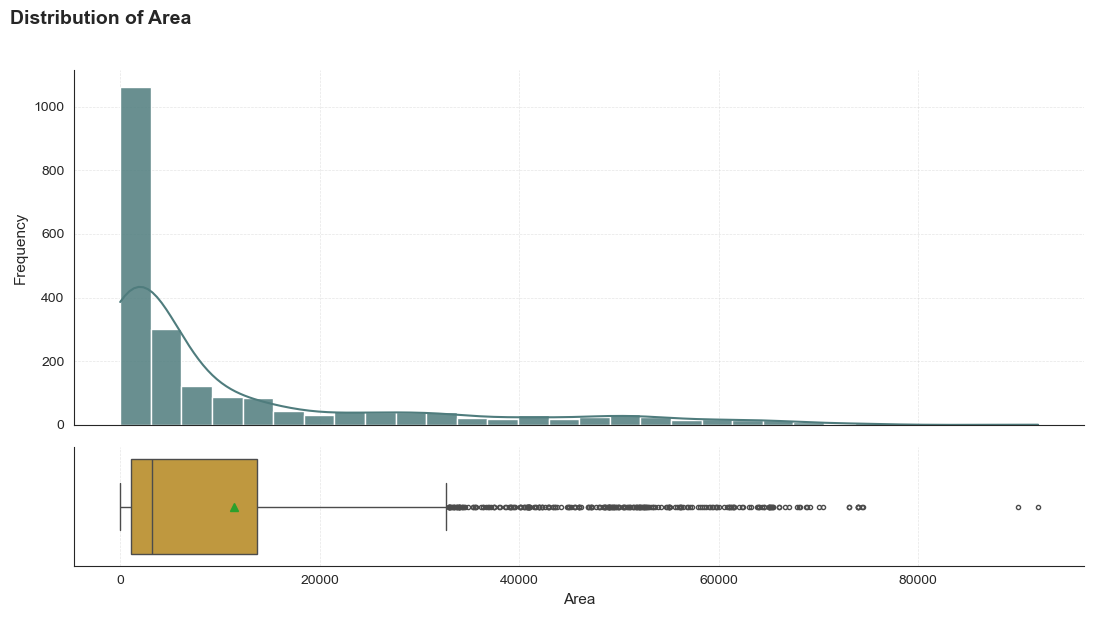

Detected type for 'production': continuous
'production': 0 missing (0.0%)
Skew: 2.000


,count,mean,std,min,25%,50%,75%,max
production,2156.0,107124.95513,169267.685375,64.0,6180.0,22921.75,126870.15,1012000.0


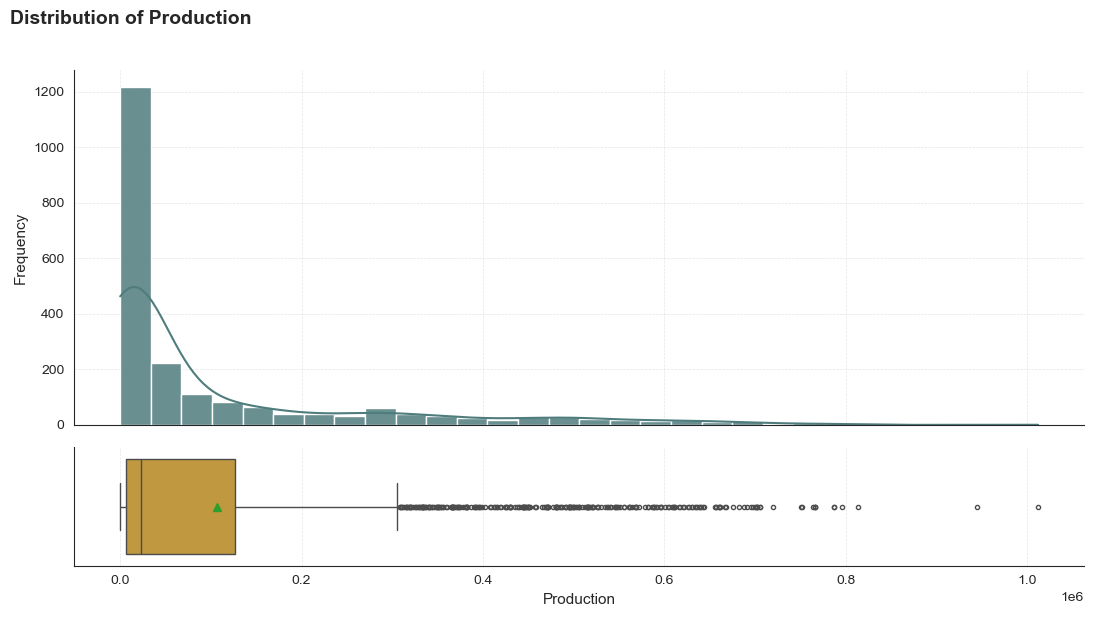

Detected type for 'yield': continuous
'yield': 0 missing (0.0%)
Skew: 0.018


,count,mean,std,min,25%,50%,75%,max
yield,2156.0,7.698448,2.565419,0.675676,5.964065,7.931647,9.462355,23.333333


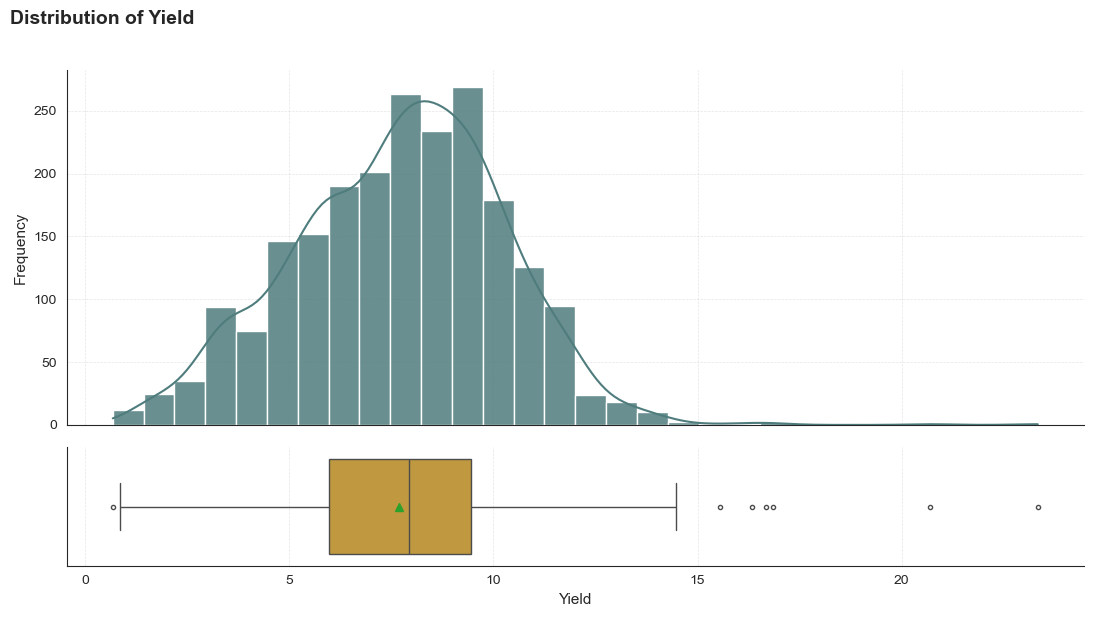

In [102]:
for c in grain_maize_df_full.columns[3:]:
    kind = infer_variable_type(grain_maize_df_full[c])
    if kind == "continuous":
        describe_variable(grain_maize_df_full, c, auto_log = False)
    else:
        describe_variable(grain_maize_df_full, c)